In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score
import shap

In [2]:
# 1. DOWNLOAD AND LOAD DATASET
path = kagglehub.dataset_download("alexkataev/bank-marketing-data-set")
csv_path = os.path.join(path, "bank-additional-full.csv")
df = pd.read_csv(csv_path, sep=';')

100%|██████████| 393k/393k [00:00<00:00, 30.4MB/s]

Extracting files...


Dataset Head:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor

/tmp/ipykernel_9495/3534018674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='viridis')


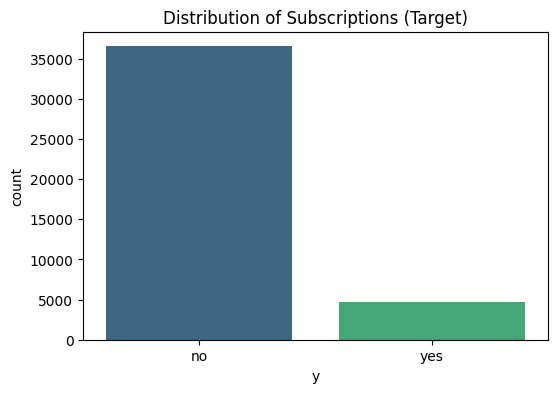

In [3]:
# 2. EXPLORATORY DATA ANALYSIS (Required for your task)
print("Dataset Head:\n", df.head())
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribution of Subscriptions (Target)')
plt.show()

In [4]:
# 3. DATA PREPROCESSING
X = df.drop('y', axis=1)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [5]:
# Label Encoding for categorical features
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# 4. MODEL TRAINING
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


Model F1-Score: 0.5181


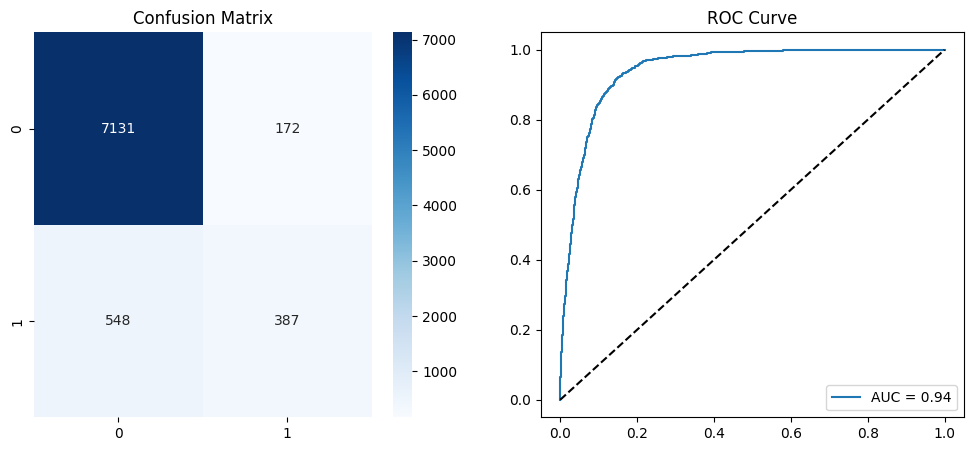

In [9]:
# 5. EVALUATION
print(f"\nModel F1-Score: {f1_score(y_test, y_pred):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('ROC Curve')
ax[1].legend()
plt.show()


--- Generating SHAP Explanation Plot ---


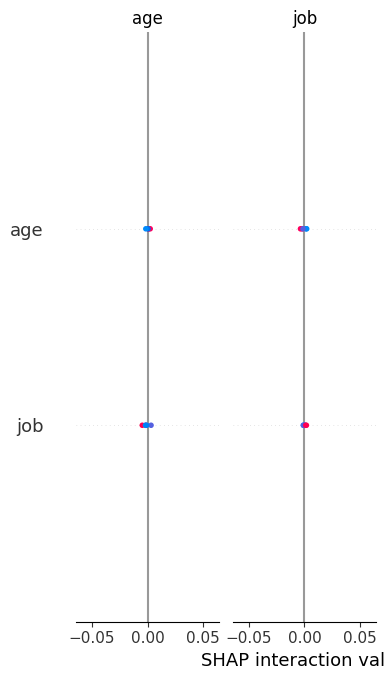

In [10]:

# 6. EXPLAINABLE AI (SHAP) - Robust Implementation
explainer = shap.TreeExplainer(model)
# Sample 5 instances for explanation
X_sample = X_test.iloc[:5]
shap_values = explainer.shap_values(X_sample)

# Handling different SHAP output formats (List vs Array)
if isinstance(shap_values, list):
    # Use the values for the 'Positive' class (index 1)
    shap_val_to_plot = shap_values[1]
else:
    # In newer SHAP versions, it might be a single array for binary
    shap_val_to_plot = shap_values

print("\n--- Generating SHAP Explanation Plot ---")
shap.summary_plot(shap_val_to_plot, X_sample)